# Multislice (Fast)
This notebook will give a general tutorial on multislice simulation in abTEM.
In comparison to all simulation discussed in the thesis, this notebooks will use the Fourier method @fourier-multislice-operator to compute the multislice much faster. 
To compute a multislice simulation we will outline the following steps:
1. Define sample (using [ASE](https://ase-lib.org/))
2. Convert sample into potential
3. Define incident beam (planewave, converged probe)
4. Run multislice simulation

In [1]:
import abtem
import ase
import matplotlib.pyplot as plt
import numpy as np

In [2]:
STO_crystal = ase.Atoms(
    "SrTiO3",
    scaled_positions=[
        (0.0, 0.0, 0.0),

        (0.5, 0.5, 0.5),

        (0.5, 0.0, 0.5),
        (0.5, 0.5, 0.0),
        (0.0, 0.5, 0.5),
    ],
    cell=[3.91270131, 3.91270131, 3.91270131, 90, 90, 90],
    pbc=True
)
# abTEM multislice requires crystals to be orthogonal
STO_orthorhombic = abtem.orthogonalize_cell(STO_crystal) 

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='y [Å]', ylabel='z [Å]'>)

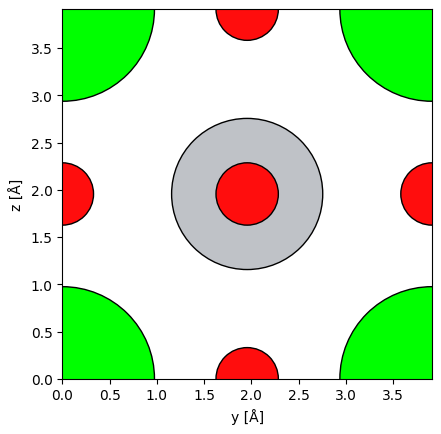

In [3]:
fig,ax = plt.subplots()
abtem.show_atoms(STO_orthorhombic,plane='yz',scale=0.5,tight_limits=True,show_periodic=True,ax=ax)

# Crystal potential

In [4]:
sampling = 0.1 #Angstrom
slice_thickness = 0.5 #Angstrom
thickness = 48 #unit cells 
sample_size = (1,1,thickness)
energy = 20e3 #eV

In [5]:
unit_cell_potential = abtem.Potential(
            STO_orthorhombic,
            sampling=sampling,
            parametrization="lobato",
            slice_thickness=slice_thickness,
            projection="finite",
        )

potential = abtem.CrystalPotential(
    unit_cell_potential,
    repetitions=sample_size,
)

# Planewave 

```{note} Here it is important that the planewave grid is matched to the potential grid

In [6]:
planewave = abtem.PlaneWave(energy=energy).match_grid(potential)

detector = abtem.PixelatedDetector(max_angle=None)

# Running the simulation

In [7]:
exitwave_pw = planewave.multislice(
    potential=potential,
    detectors=detector,
    pbar=True,
    lazy=False
    )

multislice:   0%|          | 0/384 [00:00<?, ?it/s]

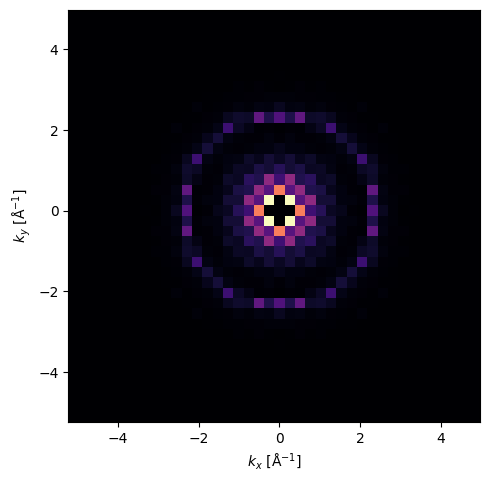

In [ ]:
exitwave_pw.block_direct().show(
    cmap='magma',
    power=0.5,
    vmin=0
)

```{note} In the plot above the incident beam is blocked out by simply setting the central pixel to 0. This is done to highlight the detail of the scattered beams since most electrons go unscattered creating a bright spot.

# CBED (Converged Beam Electron Diffraction)

For a CBED simulation, instead of using a planewave we use a abTEM probe object which has an aperture to allow different beam angles up to a certain maximum.
We set that maximum angle using the semiangle_cutoff parameter.

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

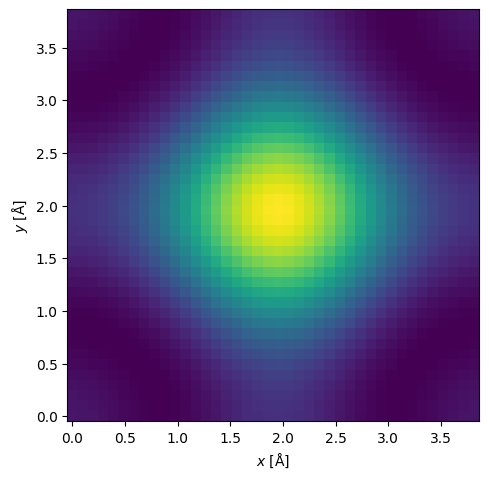

In [9]:
semiangle = 20

probe = abtem.Probe(energy=energy, semiangle_cutoff=semiangle).match_grid(potential)

probe.show()

The plot above shows the probe extending all the way to the edges of the simulation grid. 
This will cause incorrect results since the periodic boundary conditions abTEM uses will cause values to wrap over.
To fix that we extend the simulation grid by repeating the crystal potential in the x and y directions.
This was not necessary for the planewave simulation since a repeated crystal in the x and y directions would simply repeat the planewave exitwave.

In [10]:
potential_cbed = abtem.CrystalPotential(
    unit_cell_potential,
    repetitions=(8,8,thickness),
)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

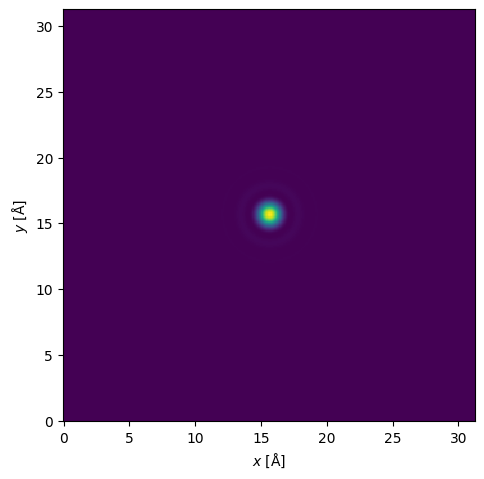

In [11]:
semiangle = 20

probe = abtem.Probe(energy=50e3, semiangle_cutoff=semiangle).match_grid(potential_cbed)

probe.show()

Now the probe is appropriately sized and we can proceed with the simulation

In [12]:
exitwave_probe = probe.multislice(
    potential=potential_cbed,
    detectors=detector,
    pbar=True,
    lazy=False
    )

multislice:   0%|          | 0/384 [00:00<?, ?it/s]

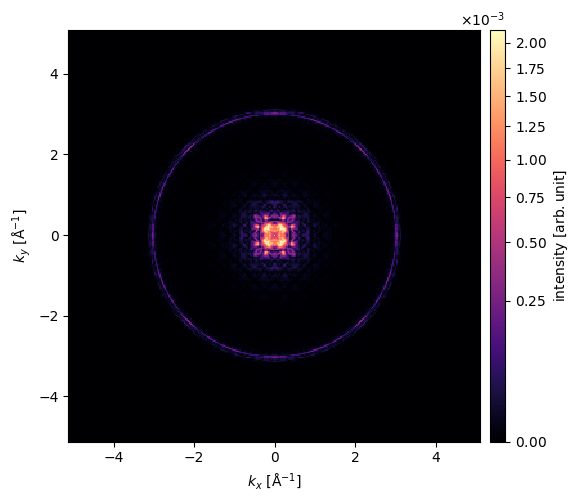

In [13]:
exitwave_probe.show(
    cmap='magma',
    power=0.5,
    vmin=0,
    cbar=True
)

# PACBED (Position Averaged CBED)
Lastly we will cover PACBED scans. 
Since at higher energies the probe size decreases even to a size smaller than the unit cells, 
there is a position dependence on the final exit wave. 
Positioning the probe directly above a heavy atom will create a different exit wave than if it were positioned somewhere between the atoms (viewed along the optical axis).
Therefore it will be interesting to scan over a range of probe positions and average the exitwaves at each position which creates a final image.
There is one small problem with this approach which is easily resolved: because our simulation is fully elastic without backscattering effects taken into account (See @FCMS), 
the average of every scan position will be the same. 
To deal with this we can average over a specific region of the detector. 
For this we use a annular detector which integrates over a region between two angles.
This gives us a measure of how much scattering is happening. 
This in turn tells us a lot about the crystal. 
Directly above a heavy atom you expect more scattering than above mostly empty space.
As explained in Section. @STEM, the PACBED scans gets blurrier at lower energies since the probe size gets physically larger.
So for this demonstration we will increase the probe energy even though this thesis is mainly focussed on lower energy simulations.

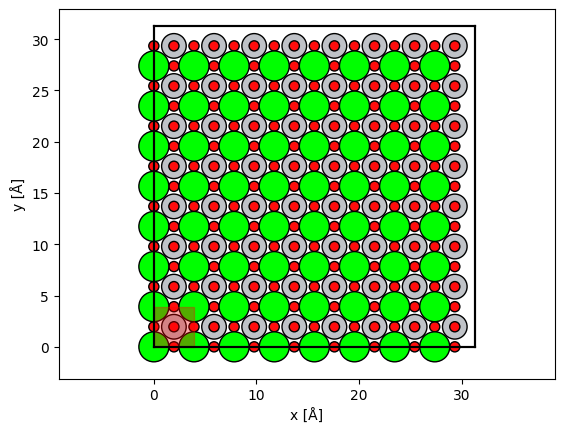

In [14]:
haadf = abtem.AnnularDetector(inner=60, outer=None)

grid_scan = abtem.GridScan(
    start=[0, 0],
    end=(STO_orthorhombic.cell[0,0]*1, STO_orthorhombic.cell[1,1]*1),
    sampling=probe.aperture.nyquist_sampling,
    potential=potential_cbed,
)

fig, ax = abtem.show_atoms(STO_orthorhombic*(8,8,1))
grid_scan.add_to_plot(ax)

In [15]:
measurements = probe.scan(potential_cbed, scan=grid_scan, detectors=haadf, lazy=False, pbar=True)

multislice:   0%|          | 0/13824 [00:00<?, ?it/s]

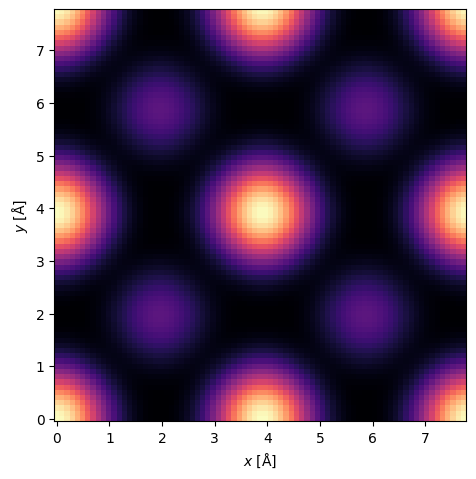

In [16]:
measurements.tile((2,2)).interpolate(sampling=0.1).show(cmap='magma')